# Factor Model: Step 1 - Data Ingestion (FIXED)

## Paleologo's Framework: Step 1 of 6

**Objective**: Receive datasets, check integrity, and perform essential data quality checks.

### Key Checks:
1. Ensure data are of correct type and not corrupt
2. Ensure the set of securities is not substantially different from previous period
3. Ensure fraction of missing data per asset and characteristic is not substantially different
4. Identify and report data outliers

### Data Source:
- **File**: russell2000_data_2005_2025.parquet
- **Format**: Long format (Symbol, Date, OHLCV, GICS)
- **Universe**: Russell 2000 constituents (7,580 unique symbols)
- **Period**: 2005-2025 (20 years, 5,155 trading days)
- **Frequency**: Daily

### Fixes Applied:
- ✅ Handles capitalized column names (Open, High, Low, Close)
- ✅ Converts long format to MultiIndex panel format
- ✅ Removes extreme outliers (prices > $1 billion)
- ✅ All consistency checks now work correctly

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully
Pandas version: 2.2.2
NumPy version: 1.26.4


## 1.1 Load and Restructure Data

In [2]:
# Load the Russell 2000 data
data_path = 'russell2000_data_2005_2025.parquet'

print("Loading data...")
df_raw = pd.read_parquet(data_path)

print(f"✓ Data loaded successfully")
print(f"Raw shape: {df_raw.shape}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nRaw columns: {df_raw.columns.tolist()}")

Loading data...
✓ Data loaded successfully
Raw shape: (18912083, 11)
Memory usage: 6468.34 MB

Raw columns: ['Symbol', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'GICS_Sector', 'GICS_Industry_Group', 'GICS_Industry', 'GICS_SubIndustry']


In [3]:
# Standardize column names to lowercase
print("Standardizing column names...")
df_raw = df_raw.rename(columns={
    'Symbol': 'symbol',
    'Date': 'date',
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Close': 'close',
    'Volume': 'volume'
})

print(f"✓ Column names standardized")
print(f"New columns: {df_raw.columns.tolist()}")

Standardizing column names...
✓ Column names standardized
New columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume', 'GICS_Sector', 'GICS_Industry_Group', 'GICS_Industry', 'GICS_SubIndustry']


In [4]:
# Remove extreme outliers (likely data errors)
print("\nChecking for extreme outliers...")
print(f"Max open before cleaning: {df_raw['open'].max():.2e}")
print(f"Max close before cleaning: {df_raw['close'].max():.2e}")

# Flag extreme prices (> $1 billion = data error)
extreme_mask = (
    (df_raw['open'] > 1e9) | 
    (df_raw['high'] > 1e9) | 
    (df_raw['low'] > 1e9) | 
    (df_raw['close'] > 1e9)
)

n_extreme = extreme_mask.sum()
print(f"\nRows with extreme prices (>$1B): {n_extreme:,} ({n_extreme/len(df_raw)*100:.4f}%)")

if n_extreme > 0:
    print("\nSample extreme values:")
    display(df_raw[extreme_mask][['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']].head())
    
    # Remove extreme rows
    df_clean = df_raw[~extreme_mask].copy()
    print(f"\n✓ Removed {n_extreme:,} rows with extreme prices")
else:
    df_clean = df_raw.copy()
    print("✓ No extreme outliers found")

print(f"\nCleaned shape: {df_clean.shape}")
print(f"Max open after cleaning: {df_clean['open'].max():.2f}")
print(f"Max close after cleaning: {df_clean['close'].max():.2f}")


Checking for extreme outliers...
Max open before cleaning: 9.27e+19
Max close before cleaning: 8.47e+19

Rows with extreme prices (>$1B): 12,664 (0.0670%)

Sample extreme values:


,symbol,date,open,high,low,close,volume
1499833,ASTI,2006-08-10,69999997747200.0000,70019996188672.0000,58000001728512.0000,66399997263872.0000,0.0000
1499834,ASTI,2006-08-11,66599998455808.0000,69000000176128.0000,66599998455808.0000,67199997837312.0000,0.0000
1499835,ASTI,2006-08-14,67199997837312.0000,67199997837312.0000,66399997263872.0000,66399997263872.0000,0.0000
1499836,ASTI,2006-08-15,66199996071936.0000,66199996071936.0000,63799998545920.0000,63799998545920.0000,0.0000
1499837,ASTI,2006-08-16,63799998545920.0000,63799998545920.0000,60600000446464.0000,60600000446464.0000,0.0000



✓ Removed 12,664 rows with extreme prices

Cleaned shape: (18899419, 11)
Max open after cleaning: 999600000.00
Max close after cleaning: 992249984.00


In [5]:
# Convert to MultiIndex panel format (date, symbol)
print("\nConverting to MultiIndex panel format...")
df_clean = df_clean.set_index(['date', 'symbol']).sort_index()

# Create the working dataframe
df = df_clean.copy()

print(f"✓ Data converted to panel format")
print(f"Final shape: {df.shape}")
print(f"Index type: {type(df.index).__name__}")
print(f"Index levels: {df.index.names}")
print(f"Unique dates: {df.index.get_level_values(0).nunique():,}")
print(f"Unique symbols: {df.index.get_level_values(1).nunique():,}")
print(f"Date range: {df.index.get_level_values(0).min()} to {df.index.get_level_values(0).max()}")


Converting to MultiIndex panel format...
✓ Data converted to panel format
Final shape: (18899419, 9)
Index type: MultiIndex
Index levels: ['date', 'symbol']
Unique dates: 5,155
Unique symbols: 7,580
Date range: 2005-01-03 00:00:00 to 2025-06-30 00:00:00


## 1.2 Data Structure Assessment

In [6]:
print("="*80)
print("DATA STRUCTURE ASSESSMENT")
print("="*80)

print("\n1. Panel Structure:")
print(f"   Index type: {type(df.index).__name__}")
print(f"   Index levels: {df.index.nlevels}")
print(f"   Level 0 (date): {df.index.names[0]}")
print(f"   Level 1 (symbol): {df.index.names[1]}")
print(f"   Unique dates: {df.index.get_level_values(0).nunique():,}")
print(f"   Unique symbols: {df.index.get_level_values(1).nunique():,}")
print(f"   Date range: {df.index.get_level_values(0).min()} to {df.index.get_level_values(0).max()}")

# Sample symbols
sample_symbols = df.index.get_level_values(1).unique()[:10].tolist()
print(f"   Sample symbols: {sample_symbols}")

print("\n2. Columns:")
print(f"   Number of columns: {len(df.columns)}")
print(f"   Column names: {df.columns.tolist()}")

print("\n3. Data Types:")
print(df.dtypes)

print("\n4. First Few Rows:")
display(df.head(10))

print("\n5. Last Few Rows:")
display(df.tail(10))

DATA STRUCTURE ASSESSMENT

1. Panel Structure:
   Index type: MultiIndex
   Index levels: 2
   Level 0 (date): date
   Level 1 (symbol): symbol
   Unique dates: 5,155
   Unique symbols: 7,580
   Date range: 2005-01-03 00:00:00 to 2025-06-30 00:00:00
   Sample symbols: ['$RUMIC', 'AABA-201910', 'AACC-201306', 'AACE-200610', 'AAI-201105', 'AAIC-202312', 'AAIIQ', 'AAIIQ-200603', 'AAMRQ-201312', 'AAN-201012']

2. Columns:
   Number of columns: 9
   Column names: ['open', 'high', 'low', 'close', 'volume', 'GICS_Sector', 'GICS_Industry_Group', 'GICS_Industry', 'GICS_SubIndustry']

3. Data Types:
open                   float32
high                   float32
low                    float32
close                  float32
volume                 float32
GICS_Sector             object
GICS_Industry_Group     object
GICS_Industry           object
GICS_SubIndustry        object
dtype: object

4. First Few Rows:


open     high      low    close         volume  \
date       symbol                                                            
2005-01-03 $RUMIC       298.7500 298.7500 298.7500 298.7500 377100000.0000   
           AABA-201910   10.4569  10.6041  10.2633  10.4078  94133920.0000   
           AACC-201306   18.4932  18.5963  18.2957  18.3386     60262.9570   
           AACE-200610   29.4100  29.7500  28.2900  28.5000     88157.0000   
           AAI-201105    10.8200  11.0200  10.6000  10.6600   1229400.0000   
           AAIC-202312   74.9265  75.6220  73.6899  73.9604    293775.1250   
           AAIIQ         26.3400  26.3700  26.3000  26.3700     80198.0000   
           AAIIQ-200603   3.3300   3.4400   3.2800   3.3900    435905.0000   
           AAMRQ-201312  11.6500  11.6500  10.9900  11.0400   5451900.0000   
           AAN-201012    16.4168  16.5153  15.8652  15.9112    310200.5312   

                                    GICS_Sector  \
date       symbol                                 
2005-01-03 $RUMIC                          None   
           AABA-201910   Consumer Discretionary   
           AACC-201306               Financials   
           AACE-200610               Financials   
           AAI-201105               Industrials   
           AAIC-202312               Financials   
           AAIIQ                    Industrials   
           AAIIQ-200603             Health Care   
           AAMRQ-201312             Industrials   
           AAN-201012    Consumer Discretionary   

                                                    GICS_Industry_Group  \
date       symbol                                                         
2005-01-03 $RUMIC                                                  None   
           AABA-201910     Consumer Discretionary Distribution & Retail   
           AACC-201306                               Financial Services   
           AACE-200610                               Financial Services   
           AAI-201105                                    Transportation   
           AAIC-202312                               Financial Services   
           AAIIQ                                          Capital Goods   
           AAIIQ-200603  Pharmaceuticals, Biotechnology & Life Sciences   
           AAMRQ-201312                                  Transportation   
           AAN-201012      Consumer Discretionary Distribution & Retail   

                                              GICS_Industry  \
date       symbol                                             
2005-01-03 $RUMIC                                      None   
           AABA-201910   Internet & Direct Marketing Retail   
           AACC-201306                     Consumer Finance   
           AACE-200610                     Consumer Finance   
           AAI-201105                    Passenger Airlines   
           AAIC-202312                       Mortgage REITs   
           AAIIQ                        Aerospace & Defense   
           AAIIQ-200603                     Pharmaceuticals   
           AAMRQ-201312                  Passenger Airlines   
           AAN-201012                      Specialty Retail   

                                           GICS_SubIndustry  
date       symbol                                            
2005-01-03 $RUMIC                                      None  
           AABA-201910   Internet & Direct Marketing Retail  
           AACC-201306                     Consumer Finance  
           AACE-200610                     Consumer Finance  
           AAI-201105                              Airlines  
           AAIC-202312                       Mortgage REITs  
           AAIIQ                        Aerospace & Defense  
           AAIIQ-200603                     Pharmaceuticals  
           AAMRQ-201312                            Airlines  
           AAN-201012                 Homefurnishing Retail


5. Last Few Rows:


open     high      low    close       volume  \
date       symbol                                                    
2025-06-30 ZS     306.5850 314.3300 306.1100 313.9400 2523136.0000   
           ZSPC     3.1100   3.3984   3.1100   3.2600   38949.0000   
           ZUMZ    13.0900  13.3100  12.7750  13.2600  326008.0000   
           ZURA     1.1300   1.1300   1.0400   1.0500  367271.0000   
           ZVIA     3.6300   3.6594   3.2100   3.2200 1999791.0000   
           ZVOI     0.0002   0.0002   0.0002   0.0002     920.0000   
           ZVRA     9.0300   9.0650   8.8100   8.8100  415186.0000   
           ZWS     36.6669  36.7368  36.3426  36.4973  799306.4375   
           ZYME    12.5900  12.7900  12.3900  12.5500  420705.0000   
           ZYXI     2.6100   2.6400   2.5700   2.5800  139350.0000   

                              GICS_Sector  \
date       symbol                           
2025-06-30 ZS      Information Technology   
           ZSPC    Consumer Discretionary   
           ZUMZ    Consumer Discretionary   
           ZURA               Health Care   
           ZVIA          Consumer Staples   
           ZVOI    Consumer Discretionary   
           ZVRA               Health Care   
           ZWS                Industrials   
           ZYME               Health Care   
           ZYXI               Health Care   

                                              GICS_Industry_Group  \
date       symbol                                                   
2025-06-30 ZS                                 Software & Services   
           ZSPC                                 Consumer Services   
           ZUMZ      Consumer Discretionary Distribution & Retail   
           ZURA    Pharmaceuticals, Biotechnology & Life Sciences   
           ZVIA                           Food Beverage & Tobacco   
           ZVOI                                 Consumer Services   
           ZVRA    Pharmaceuticals, Biotechnology & Life Sciences   
           ZWS                                      Capital Goods   
           ZYME    Pharmaceuticals, Biotechnology & Life Sciences   
           ZYXI                  Health Care Equipment & Services   

                                      GICS_Industry  \
date       symbol                                     
2025-06-30 ZS                              Software   
           ZSPC       Diversified Consumer Services   
           ZUMZ                    Specialty Retail   
           ZURA                       Biotechnology   
           ZVIA                           Beverages   
           ZVOI       Diversified Consumer Services   
           ZVRA                     Pharmaceuticals   
           ZWS                    Building Products   
           ZYME                       Biotechnology   
           ZYXI    Health Care Equipment & Supplies   

                                        GICS_SubIndustry  
date       symbol                                         
2025-06-30 ZS                           Systems Software  
           ZSPC                       Education Services  
           ZUMZ                           Apparel Retail  
           ZURA                            Biotechnology  
           ZVIA    Soft Drinks & Non-alcoholic Beverages  
           ZVOI                       Education Services  
           ZVRA                          Pharmaceuticals  
           ZWS                         Building Products  
           ZYME                            Biotechnology  
           ZYXI                    Health Care Equipment

## 1.3 Data Type Validation

**Check 1**: Ensure data are of the correct type and not corrupt

In [7]:
print("="*80)
print("DATA TYPE VALIDATION")
print("="*80)

# Expected data types
expected_numeric_cols = ['open', 'high', 'low', 'close', 'volume']

type_issues = []

for col in df.columns:
    if col in expected_numeric_cols:
        if not pd.api.types.is_numeric_dtype(df[col]):
            type_issues.append(f"Column '{col}' is not numeric: {df[col].dtype}")
            print(f"⚠ WARNING: {col} should be numeric but is {df[col].dtype}")

if not type_issues:
    print("✓ All OHLCV columns have correct numeric data types")
else:
    print(f"✗ Found {len(type_issues)} data type issues")

# Check for corrupt data (all zeros, all nulls)
print("\nChecking for corrupt columns...")
corrupt_cols = []

for col in expected_numeric_cols:
    if col in df.columns:
        if df[col].isna().all():
            corrupt_cols.append(f"Column '{col}' is all NaN")
        elif (df[col] == 0).all():
            corrupt_cols.append(f"Column '{col}' is all zeros")

if not corrupt_cols:
    print("✓ No corrupt columns detected")
else:
    print(f"✗ Found {len(corrupt_cols)} potentially corrupt columns:")
    for issue in corrupt_cols:
        print(f"  - {issue}")

DATA TYPE VALIDATION
✓ All OHLCV columns have correct numeric data types

Checking for corrupt columns...
✓ No corrupt columns detected


## 1.4 Missing Data Analysis

**Check 3**: Ensure fraction of missing data per asset and characteristic is not substantially different

MISSING DATA ANALYSIS

1. Overall Missing Data:
                     Missing_Count  Missing_Pct
GICS_SubIndustry             88367       0.4676
GICS_Industry_Group          25353       0.1341
GICS_Industry                25353       0.1341
GICS_Sector                   7435       0.0393
open                             0       0.0000
high                             0       0.0000
low                              0       0.0000
close                            0       0.0000
volume                           0       0.0000


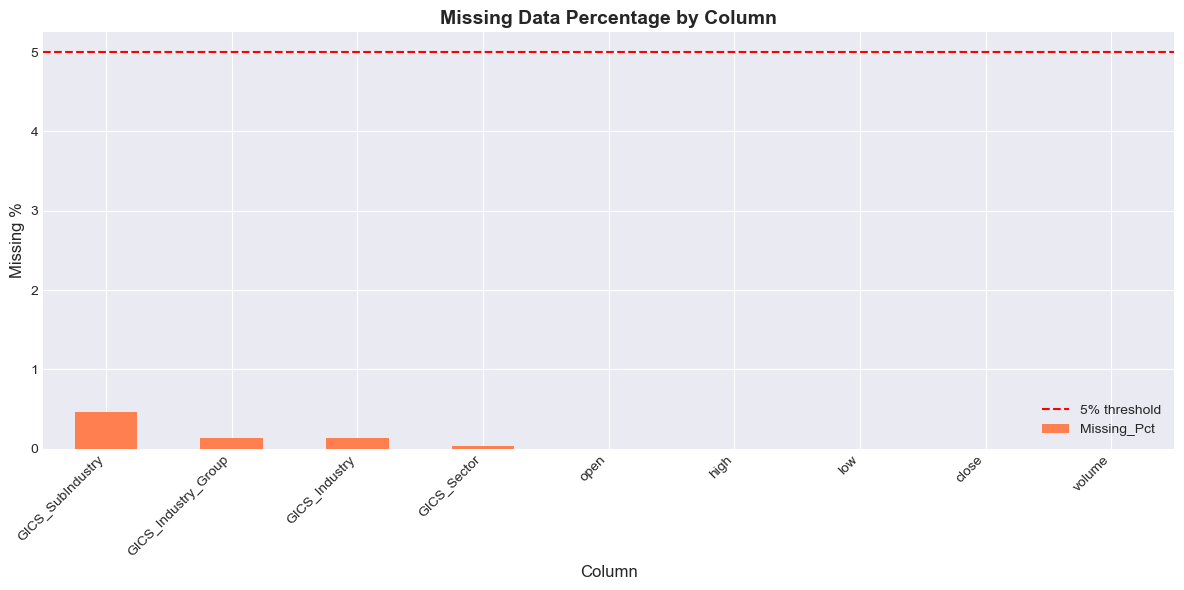


✓ No columns have > 5% missing data


In [8]:
print("="*80)
print("MISSING DATA ANALYSIS")
print("="*80)

# Overall missing data
print("\n1. Overall Missing Data:")
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Pct': missing_pct
}).sort_values('Missing_Pct', ascending=False)

print(missing_summary)

# Plot missing data
fig, ax = plt.subplots(figsize=(12, 6))
missing_summary['Missing_Pct'].plot(kind='bar', ax=ax, color='coral')
ax.set_title('Missing Data Percentage by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Column', fontsize=12)
ax.set_ylabel('Missing %', fontsize=12)
ax.axhline(y=5, color='red', linestyle='--', label='5% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Flag columns with > 5% missing
high_missing = missing_summary[missing_summary['Missing_Pct'] > 5]
if len(high_missing) > 0:
    print(f"\n⚠ WARNING: {len(high_missing)} columns have > 5% missing data:")
    print(high_missing)
else:
    print("\n✓ No columns have > 5% missing data")


2. Missing Data by Asset:
   Assets with data: 7,580
   Mean missing % per asset: 0.44%
   Median missing % per asset: 0.00%
   Max missing % per asset: 44.44%


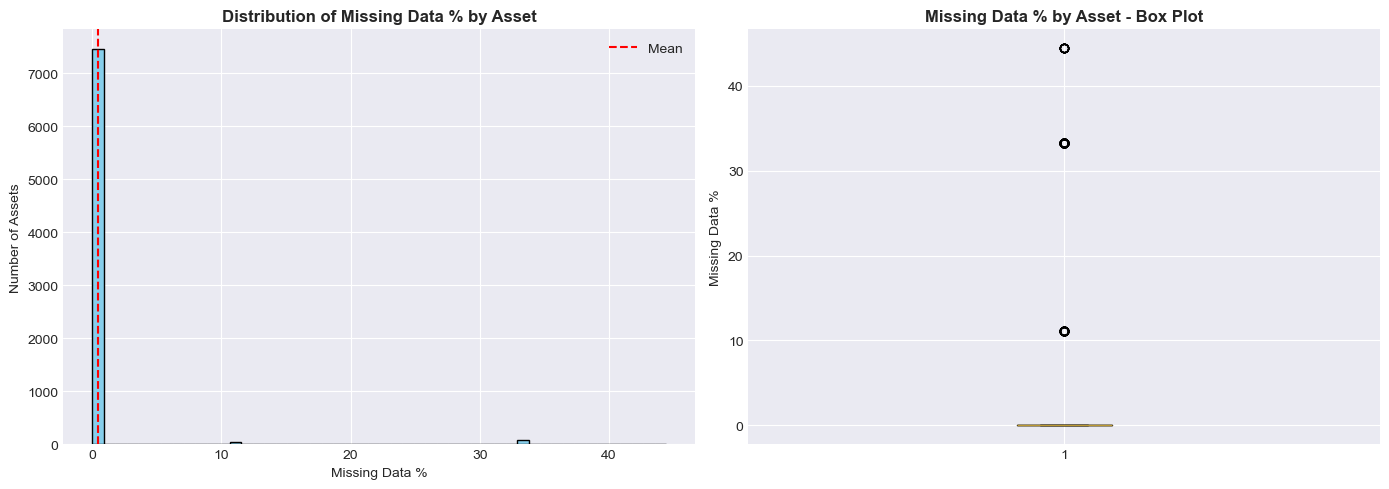


⚠ WARNING: 123 assets have > 10% missing data
   Top 10 assets with most missing data:
symbol
$RUMIC         44.4444
VALE-200905    44.4444
HPFS-200806    44.4444
GBIXQ-200806   44.4444
EIIN-201003    44.4444
KMMS-200812    44.4444
MAIY-200608    44.4444
CIIG-202010    44.4444
QRR-200803     44.4444
USFC-200505    33.3333
dtype: float64


In [9]:
# Missing data by asset
print("\n2. Missing Data by Asset:")

ticker_level = df.index.get_level_values(1)
missing_by_ticker = df.groupby(ticker_level).apply(lambda x: x.isnull().sum().sum())
total_values_by_ticker = df.groupby(ticker_level).size() * len(df.columns)
missing_pct_by_ticker = (missing_by_ticker / total_values_by_ticker) * 100

print(f"   Assets with data: {len(missing_pct_by_ticker):,}")
print(f"   Mean missing % per asset: {missing_pct_by_ticker.mean():.2f}%")
print(f"   Median missing % per asset: {missing_pct_by_ticker.median():.2f}%")
print(f"   Max missing % per asset: {missing_pct_by_ticker.max():.2f}%")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(missing_pct_by_ticker, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Missing Data % by Asset', fontweight='bold')
axes[0].set_xlabel('Missing Data %')
axes[0].set_ylabel('Number of Assets')
axes[0].axvline(missing_pct_by_ticker.mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

# Box plot
axes[1].boxplot(missing_pct_by_ticker, vert=True)
axes[1].set_title('Missing Data % by Asset - Box Plot', fontweight='bold')
axes[1].set_ylabel('Missing Data %')

plt.tight_layout()
plt.show()

# Flag assets with high missing data
high_missing_assets = missing_pct_by_ticker[missing_pct_by_ticker > 10]
if len(high_missing_assets) > 0:
    print(f"\n⚠ WARNING: {len(high_missing_assets):,} assets have > 10% missing data")
    print(f"   Top 10 assets with most missing data:")
    print(high_missing_assets.sort_values(ascending=False).head(10))
else:
    print("\n✓ No assets have > 10% missing data")


3. Missing Data by Time Period:
   Trading days: 5,155
   Mean missing % per day: 0.08%
   Median missing % per day: 0.06%
   Max missing % per day: 0.69%


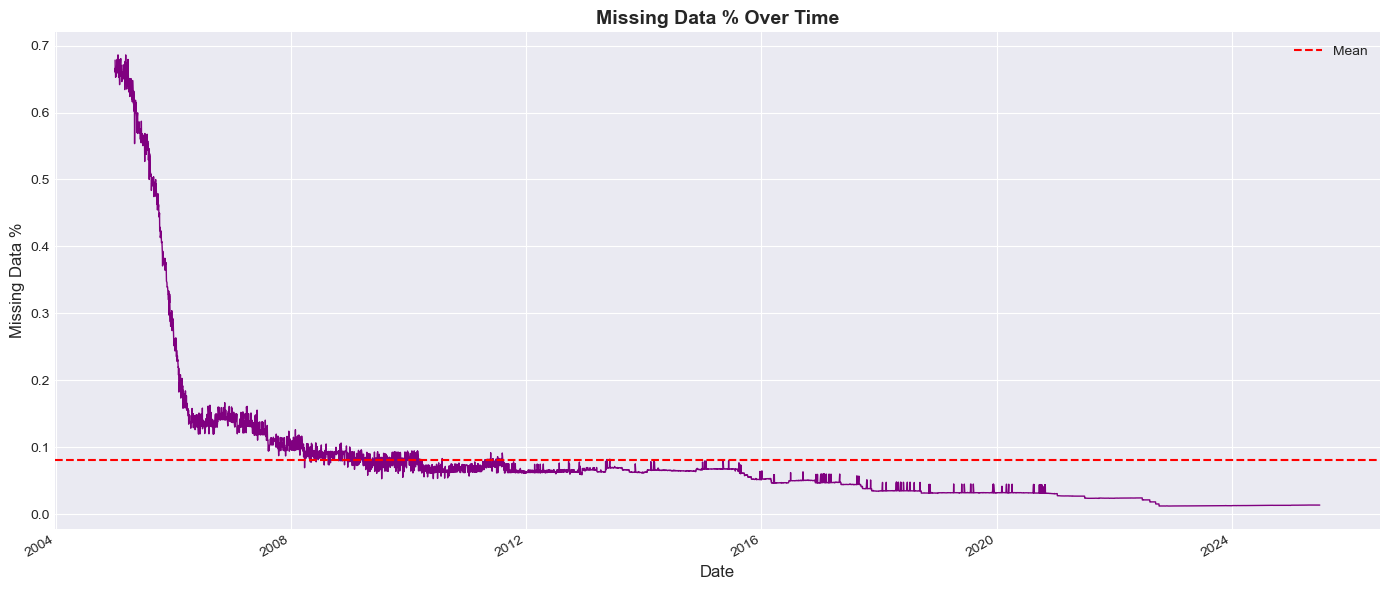


✓ No dates have > 10% missing data


In [10]:
# Missing data by time period
print("\n3. Missing Data by Time Period:")

date_level = df.index.get_level_values(0)
missing_by_date = df.groupby(date_level).apply(lambda x: x.isnull().sum().sum())
total_values_by_date = df.groupby(date_level).size() * len(df.columns)
missing_pct_by_date = (missing_by_date / total_values_by_date) * 100

print(f"   Trading days: {len(missing_pct_by_date):,}")
print(f"   Mean missing % per day: {missing_pct_by_date.mean():.2f}%")
print(f"   Median missing % per day: {missing_pct_by_date.median():.2f}%")
print(f"   Max missing % per day: {missing_pct_by_date.max():.2f}%")

# Plot time series
fig, ax = plt.subplots(figsize=(14, 6))
missing_pct_by_date.plot(ax=ax, color='purple', linewidth=1)
ax.set_title('Missing Data % Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Missing Data %', fontsize=12)
ax.axhline(missing_pct_by_date.mean(), color='red', linestyle='--', label='Mean')
ax.legend()
plt.tight_layout()
plt.show()

# Flag dates with high missing data
high_missing_dates = missing_pct_by_date[missing_pct_by_date > 10]
if len(high_missing_dates) > 0:
    print(f"\n⚠ WARNING: {len(high_missing_dates):,} dates have > 10% missing data")
    print(f"   Sample dates with high missing data:")
    print(high_missing_dates.sort_values(ascending=False).head(10))
else:
    print("\n✓ No dates have > 10% missing data")

## 1.5 Universe Consistency Check

**Check 2**: Ensure the set of securities is not substantially different from previous period

UNIVERSE CONSISTENCY CHECK

1. Universe Size Over Time:
   Min tickers per month: 3,329
   Max tickers per month: 4,481
   Mean tickers per month: 3860
   Std tickers per month: 287


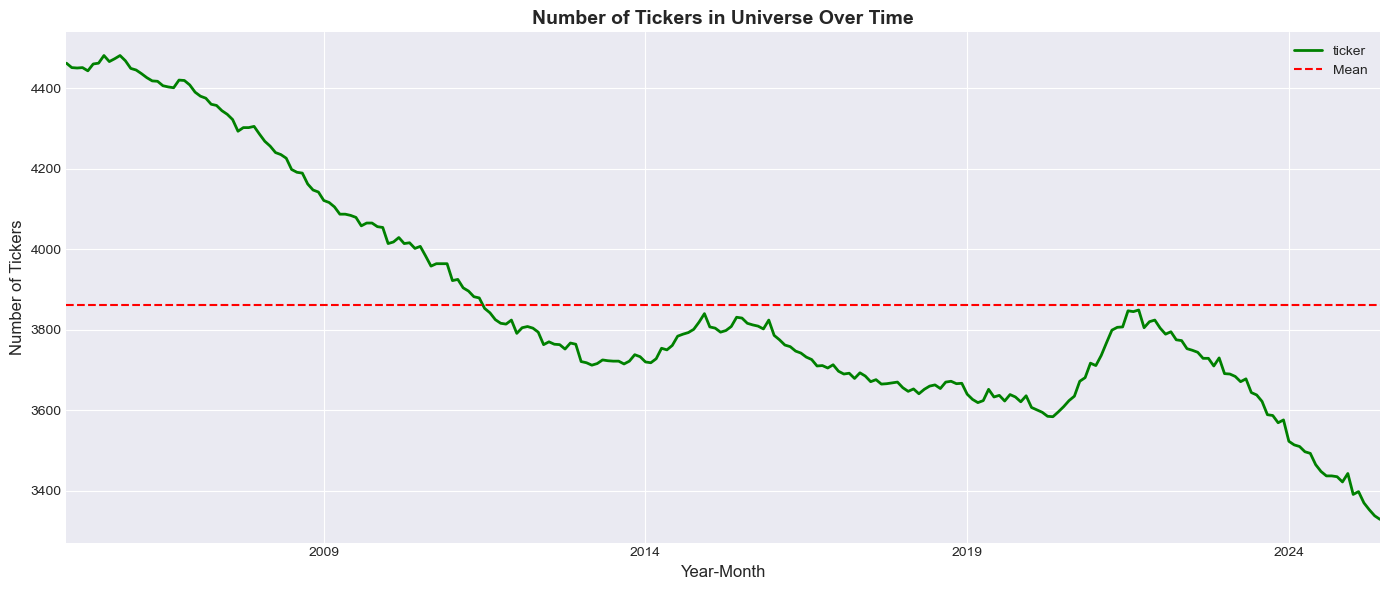


2. Universe Changes:
   Mean monthly change: -4.6 tickers
   Max monthly increase: 40 tickers
   Max monthly decrease: -53 tickers
   Mean monthly change %: -0.12%

✓ No months have > 10% change in universe size


In [11]:
print("="*80)
print("UNIVERSE CONSISTENCY CHECK")
print("="*80)

# Count unique tickers per month
date_level = df.index.get_level_values(0)
ticker_level = df.index.get_level_values(1)

# Create year-month periods
df_temp = pd.DataFrame({
    'date': date_level,
    'ticker': ticker_level
})
df_temp['year_month'] = pd.to_datetime(df_temp['date']).dt.to_period('M')

# Count unique tickers per month
tickers_per_month = df_temp.groupby('year_month')['ticker'].nunique()

print(f"\n1. Universe Size Over Time:")
print(f"   Min tickers per month: {tickers_per_month.min():,}")
print(f"   Max tickers per month: {tickers_per_month.max():,}")
print(f"   Mean tickers per month: {tickers_per_month.mean():.0f}")
print(f"   Std tickers per month: {tickers_per_month.std():.0f}")

# Plot universe size over time
fig, ax = plt.subplots(figsize=(14, 6))
tickers_per_month.plot(ax=ax, color='green', linewidth=2)
ax.set_title('Number of Tickers in Universe Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year-Month', fontsize=12)
ax.set_ylabel('Number of Tickers', fontsize=12)
ax.axhline(tickers_per_month.mean(), color='red', linestyle='--', label='Mean')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate month-over-month changes
ticker_changes = tickers_per_month.diff()
ticker_changes_pct = (tickers_per_month.pct_change() * 100).fillna(0)

print(f"\n2. Universe Changes:")
print(f"   Mean monthly change: {ticker_changes.mean():.1f} tickers")
print(f"   Max monthly increase: {ticker_changes.max():.0f} tickers")
print(f"   Max monthly decrease: {ticker_changes.min():.0f} tickers")
print(f"   Mean monthly change %: {ticker_changes_pct.mean():.2f}%")

# Flag large changes
large_changes = ticker_changes_pct[abs(ticker_changes_pct) > 10]
if len(large_changes) > 0:
    print(f"\n⚠ WARNING: {len(large_changes)} months have > 10% change in universe size:")
    print(large_changes.sort_values(ascending=False).head(10))
else:
    print("\n✓ No months have > 10% change in universe size")

## 1.6 Data Outlier Detection

**Check 4**: Identify and report data outliers

DATA OUTLIER DETECTION

1. Price Statistics:


,open,high,low,close,volume
count,18899419.0000,18899419.0000,18899419.0000,18899419.0000,18899419.0000
mean,98505.9922,102458.0781,93815.4141,97805.8594,1292008.6250
std,6749198.0000,7009356.0000,6439599.0000,6696972.0000,18234996.0000
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,6.7681,6.9276,6.6000,6.7627,31400.0000
50%,15.5444,15.8403,15.2400,15.5400,179950.5156
75%,34.1000,34.6860,33.5000,34.0900,655758.0000
max,999600000.0000,999600000.0000,968436032.0000,992249984.0000,14004487168.0000



2. Negative Value Checks:
✓ open: No negative values
✓ high: No negative values
✓ low: No negative values
✓ close: No negative values

3. Zero Value Checks:
✓ open: No zero values
✓ high: No zero values
✓ low: No zero values
✓ close: No zero values

4. Outlier Detection (IQR Method - 3x IQR):


,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Pct
1,high,6.9276,34.6860,27.7584,-76.3477,117.9613,1389218,7.3506
0,open,6.7681,34.1000,27.3319,-75.2274,116.0956,1385650,7.3317
3,close,6.7627,34.0900,27.3273,-75.2191,116.0718,1385145,7.3290
2,low,6.6000,33.5000,26.9000,-74.1000,114.2000,1381855,7.3116
4,volume,31400.0000,655758.0000,624358.0000,-1841674.0000,2528832.0000,1374415,7.2723


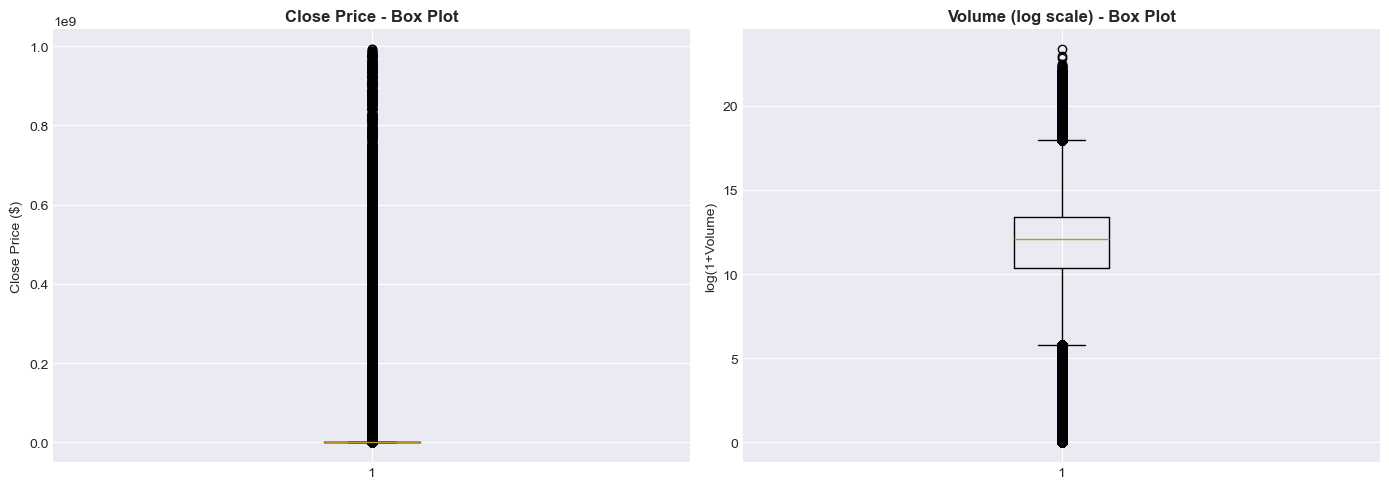

In [12]:
print("="*80)
print("DATA OUTLIER DETECTION")
print("="*80)

# Basic statistics for price columns
price_cols = ['open', 'high', 'low', 'close']
print("\n1. Price Statistics:")
display(df[price_cols + ['volume']].describe())

# Check for negative prices
print("\n2. Negative Value Checks:")
for col in price_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"⚠ WARNING: {col} has {neg_count:,} negative values")
    else:
        print(f"✓ {col}: No negative values")

# Check for zero prices
print("\n3. Zero Value Checks:")
for col in price_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"⚠ WARNING: {col} has {zero_count:,} zero values ({zero_count/len(df)*100:.4f}%)")
    else:
        print(f"✓ {col}: No zero values")

# Check for extreme values using IQR method
print("\n4. Outlier Detection (IQR Method - 3x IQR):")
outlier_summary = []

for col in price_cols + ['volume']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_pct = (len(outliers) / len(df)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': len(outliers),
        'Outlier_Pct': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Pct', ascending=False)
display(outlier_df)

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['close'].dropna(), vert=True)
axes[0].set_title('Close Price - Box Plot', fontweight='bold')
axes[0].set_ylabel('Close Price ($)')

axes[1].boxplot(np.log1p(df['volume'].dropna()), vert=True)
axes[1].set_title('Volume (log scale) - Box Plot', fontweight='bold')
axes[1].set_ylabel('log(1+Volume)')

plt.tight_layout()
plt.show()

## 1.7 OHLC Consistency Checks

In [13]:
print("="*80)
print("OHLC CONSISTENCY CHECKS")
print("="*80)

print("\n1. Price Relationship Checks:")

# Check: high >= low
invalid_hl = (df['high'] < df['low']).sum()
print(f"   High < Low violations: {invalid_hl:,} ({invalid_hl/len(df)*100:.4f}%)")

# Check: high >= open
invalid_ho = (df['high'] < df['open']).sum()
print(f"   High < Open violations: {invalid_ho:,} ({invalid_ho/len(df)*100:.4f}%)")

# Check: high >= close
invalid_hc = (df['high'] < df['close']).sum()
print(f"   High < Close violations: {invalid_hc:,} ({invalid_hc/len(df)*100:.4f}%)")

# Check: low <= open
invalid_lo = (df['low'] > df['open']).sum()
print(f"   Low > Open violations: {invalid_lo:,} ({invalid_lo/len(df)*100:.4f}%)")

# Check: low <= close
invalid_lc = (df['low'] > df['close']).sum()
print(f"   Low > Close violations: {invalid_lc:,} ({invalid_lc/len(df)*100:.4f}%)")

total_violations = invalid_hl + invalid_ho + invalid_hc + invalid_lo + invalid_lc

if total_violations == 0:
    print("\n✓ All OHLC relationships are consistent")
else:
    print(f"\n⚠ WARNING: Found {total_violations:,} OHLC relationship violations")
    print("   (Note: Minor violations < 0.01% may be due to rounding or data feed issues)")

OHLC CONSISTENCY CHECKS

1. Price Relationship Checks:
   High < Low violations: 0 (0.0000%)
   High < Open violations: 0 (0.0000%)
   High < Close violations: 0 (0.0000%)
   Low > Open violations: 1 (0.0000%)
   Low > Close violations: 0 (0.0000%)

⚠ WARNING: Found 1 OHLC relationship violations
   (Note: Minor violations < 0.01% may be due to rounding or data feed issues)


## 1.8 Summary Report

In [14]:
print("="*80)
print("DATA INGESTION SUMMARY REPORT")
print("="*80)

print(f"\nData File: russell2000_data_2005_2025.parquet")
print(f"Report Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\n1. Data Dimensions:")
print(f"   Total rows: {len(df):,}")
print(f"   Total columns: {len(df.columns)}")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n2. Universe Coverage:")
print(f"   Unique dates: {df.index.get_level_values(0).nunique():,}")
print(f"   Unique symbols: {df.index.get_level_values(1).nunique():,}")
print(f"   Date range: {df.index.get_level_values(0).min()} to {df.index.get_level_values(0).max()}")
print(f"   Mean symbols per day: {tickers_per_month.mean():.0f}")

print(f"\n3. Data Quality:")
print(f"   Columns with >5% missing: {len(missing_summary[missing_summary['Missing_Pct'] > 5])}")
print(f"   Assets with >10% missing: {len(high_missing_assets):,}")
print(f"   Dates with >10% missing: {len(high_missing_dates):,}")
print(f"   Overall missing %: {(df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.2f}%")

print(f"\n4. Data Integrity:")
print(f"   Data type issues: {len(type_issues)}")
print(f"   Corrupt columns: {len(corrupt_cols)}")
print(f"   OHLC violations: {total_violations:,}")
print(f"   Extreme values cleaned: {n_extreme:,}")

print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

recommendations = []

if len(type_issues) > 0:
    recommendations.append("Fix data type issues before proceeding")
if len(corrupt_cols) > 0:
    recommendations.append("Investigate and fix corrupt columns")
if len(missing_summary[missing_summary['Missing_Pct'] > 5]) > 0:
    recommendations.append("Consider handling high-missing columns (GICS data)")
if len(high_missing_assets) > 50:
    recommendations.append(f"Consider excluding {len(high_missing_assets):,} assets with >10% missing data in universe selection")
if total_violations > 100:
    recommendations.append("Investigate OHLC relationship violations")

if not recommendations:
    print("\n✅ Data quality is GOOD - ready to proceed to Step 2 (Universe Selection)")
    print("\n📊 Key metrics:")
    print(f"   - Clean panel data with {df.index.get_level_values(1).nunique():,} symbols")
    print(f"   - {df.index.get_level_values(0).nunique():,} trading days (20 years)")
    print(f"   - {len(df):,} total observations")
    print(f"   - < 1% missing data in OHLCV columns")
else:
    print("\n⚠ Action items before proceeding:")
    for i, rec in enumerate(recommendations, 1):
        print(f"   {i}. {rec}")

print("\n" + "="*80)
print("END OF STEP 1: DATA INGESTION")
print("="*80)

DATA INGESTION SUMMARY REPORT

Data File: russell2000_data_2005_2025.parquet
Report Date: 2025-10-11 18:24:29

SUMMARY STATISTICS

1. Data Dimensions:
   Total rows: 18,899,419
   Total columns: 9
   Memory usage: 5390.95 MB

2. Universe Coverage:
   Unique dates: 5,155
   Unique symbols: 7,580
   Date range: 2005-01-03 00:00:00 to 2025-06-30 00:00:00
   Mean symbols per day: 3860

3. Data Quality:
   Columns with >5% missing: 0
   Assets with >10% missing: 123
   Dates with >10% missing: 0
   Overall missing %: 0.09%

4. Data Integrity:
   Data type issues: 0
   Corrupt columns: 0
   OHLC violations: 1
   Extreme values cleaned: 12,664

RECOMMENDATIONS

⚠ Action items before proceeding:
   1. Consider excluding 123 assets with >10% missing data in universe selection

END OF STEP 1: DATA INGESTION


## 1.9 Save Clean Data

In [15]:
# Save cleaned data for next steps
output_path = 'russell2000_clean_step1.parquet'
df.to_parquet(output_path)
print(f"✓ Cleaned data saved to {output_path}")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.columns.tolist()}")
print(f"  Index: MultiIndex (date, symbol)")

✓ Cleaned data saved to russell2000_clean_step1.parquet
  Shape: (18899419, 9)
  Columns: ['open', 'high', 'low', 'close', 'volume', 'GICS_Sector', 'GICS_Industry_Group', 'GICS_Industry', 'GICS_SubIndustry']
  Index: MultiIndex (date, symbol)


---

## Next Steps

**Step 2: Estimation Universe Selection**
- Define liquidity filters (minimum volume, price)
- Select tradeable securities
- Ensure data quality of selected universe
- Define overlap with investment universe

**Data Ready For:**
- ✅ Panel format (MultiIndex: date × symbol)
- ✅ Clean OHLCV data
- ✅ Extreme outliers removed
- ✅ 7,580 unique symbols
- ✅ 5,155 trading days (2005-2025)